### 安裝套件

In [19]:
!pip install gensim


In [20]:
!pip install gdown


In [21]:
!pip install nltk

# A.	用不同抽樣比例的Wikipedia訓練模型的差異性分析

### Data Pre-processing


In [5]:
import pandas as pd

In [1]:
# 下載 Google Analogy Dataset（questions-words.txt）
# 用途：後續用來評估 word embedding（例如 Word2Vec）的 analogy 任務表現

!wget http://download.tensorflow.org/data/questions-words.txt


--2025-09-11 14:47:31--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 142.250.198.91, 142.250.66.91, 142.250.204.59, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.250.198.91|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.05s   

2025-09-11 14:47:31 (11.2 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [3]:
# =========================
# Preprocess：讀入 analogy 資料集
# =========================
# 格式：
# - 分段標題行以 ":" 開頭（例如 ": capital-common-countries"）
# - 類比題每行為四個 token："a b c d"，代表 a:b = c:d

file_name = "questions-words"
with open(f"{file_name}.txt", "r") as f:
    # 讀完整檔案後依行切開（每個元素是一行字串，不含換行符號）
    data = f.read().splitlines()

# =========================
# 快速抽樣檢查前 10 行
# =========================
for entry in data[:10]:
    print(entry)


: capital-common-countries
Athens Greece Baghdad Iraq
Athens Greece Bangkok Thailand
Athens Greece Beijing China
Athens Greece Berlin Germany
Athens Greece Bern Switzerland
Athens Greece Cairo Egypt
Athens Greece Canberra Australia
Athens Greece Hanoi Vietnam
Athens Greece Havana Cuba


In [10]:
# TODO1: 將 questions-words.txt 解析成 pd.DataFrame
# 欄位：
# Question    : "a b c d"（四詞類比題，一行一題）
# Category    : Semantic / Syntactic
# SubCategory : 子類別名稱

import pandas as pd

file_name = "questions-words.txt"

# 讀檔：逐行 strip，並略過空白行（避免後續 split 出空 token）
with open(file_name, "r", encoding="utf-8") as f:
    lines = [ln.strip() for ln in f if ln.strip()]

records = []
header_count = 0      # 計算是第幾個子類別標題（以 ":" 開頭的行）
cat_type = None       # 存大類：Semantic / Syntactic
subcat_type = None    # 存子類別標題

for line in lines:
    if line.startswith(":"):
        # 子類別標題
        header_count += 1
        # 子類別名稱：去掉開頭 ":"，並去掉多餘空白
        subcat_type = line.lstrip(":").strip()
        # 大類：前 5 段 Semantic，後 Syntactic
        cat_type = "Semantic" if header_count <= 5 else "Syntactic"
    else:
        # 題目
        w = line.split()

        # 防呆：len(w) 必須等於 4，subcat_type 不能是 None（代表必須先讀到 ":" 標題，才開始收題目）
        if len(w) == 4 and subcat_type is not None:
            # 題目存成單一字串，方便你後續再 split 或做向量運算
            question = " ".join(w)

            records.append({
                "Question": question,
                "Category": cat_type,
                "SubCategory": subcat_type,
            })

# 建DataFrame
df = pd.DataFrame.from_records(records, columns=["Question", "Category", "SubCategory"])


# ===== 檢查 =======

# 前 10 筆
print(df.head(10))

# 總筆數
print("總筆數：", len(df))

# 類別分佈
print(df["Category"].value_counts())




                           Question  Category                 SubCategory
0        Athens Greece Baghdad Iraq  Semantic  : capital-common-countries
1    Athens Greece Bangkok Thailand  Semantic  : capital-common-countries
2       Athens Greece Beijing China  Semantic  : capital-common-countries
3      Athens Greece Berlin Germany  Semantic  : capital-common-countries
4    Athens Greece Bern Switzerland  Semantic  : capital-common-countries
5         Athens Greece Cairo Egypt  Semantic  : capital-common-countries
6  Athens Greece Canberra Australia  Semantic  : capital-common-countries
7       Athens Greece Hanoi Vietnam  Semantic  : capital-common-countries
8         Athens Greece Havana Cuba  Semantic  : capital-common-countries
9    Athens Greece Helsinki Finland  Semantic  : capital-common-countries
總筆數： 19544
Category
Syntactic    10675
Semantic      8869
Name: count, dtype: int64


In [11]:
df.head(10)

,Question,Category,SubCategory
0,Athens Greece Baghdad Iraq,Semantic,: capital-common-countries
1,Athens Greece Bangkok Thailand,Semantic,: capital-common-countries
2,Athens Greece Beijing China,Semantic,: capital-common-countries
3,Athens Greece Berlin Germany,Semantic,: capital-common-countries
4,Athens Greece Bern Switzerland,Semantic,: capital-common-countries
5,Athens Greece Cairo Egypt,Semantic,: capital-common-countries
6,Athens Greece Canberra Australia,Semantic,: capital-common-countries
7,Athens Greece Hanoi Vietnam,Semantic,: capital-common-countries
8,Athens Greece Havana Cuba,Semantic,: capital-common-countries
9,Athens Greece Helsinki Finland,Semantic,: capital-common-countries


In [21]:
df.to_csv("questions-words.csv", index=False)

### Use pre-trained word embeddings （還未使用Wikipedia訓練）

In [4]:
# TODO2: Get predictions of the analogy task using pre-trained word embeddings (10%)
# Load the word embedding model with Gensim
import gensim
import gensim.downloader as api

MODEL_NAME = "glove-wiki-gigaword-100"
# 讀取 analogy 題目資料
data = pd.read_csv("questions-words.csv")

# 載入預訓練詞向量模型
model = gensim.downloader.load(MODEL_NAME)
print("The Gensim model loaded successfully!")


The Gensim model loaded successfully!


In [5]:
from tqdm import tqdm
# =========================
# Analogy 預測：逐題做 b + c - a 的向量運算
# 輸出：
# preds: 每題的模型預測；若無法預測則用特殊 token 表示（<OOV> / <None>）
# golds: 每題的標準答案 d
# =========================
preds = []
golds = []

# TODO2: 使用預訓練詞向量做 analogy 任務預測，保留gold answer以便評估
for analogy in tqdm(data["Question"]):
    
    # 1.Unpack 四個詞
    a, b, c, d = analogy.lower().split()
    golds.append(d) # 存標準答案
    # 2.檢查：若 a/b/c 任一詞不在詞向量，就無法做向量計算
    if not all(w in model.key_to_index for w in (a, b, c)):
        preds.append("<OOV>")
        continue
    # 3.類比向量運算：
    #   vec(d) ≈ vec(b) - vec(a) + vec(c)
    try:
        candidates = model.most_similar(
            positive=[b, c],  # + word_b + word_c
            negative=[a],     # - word_a
            topn=10           # 多抓幾個以便過濾
        )

        #避免把題目的三個輸入詞(a,b,c)當成答案
        banned = {a, b, c}
        pred = next((w for w, _ in candidates if w not in banned), "<None>")

        #保存模型預測
        preds.append(pred)
        
    except KeyError:
        # 極少數情況（例如詞向量取用例外）
        preds.append("<OOV>")

100%|██████████| 19544/19544 [01:47<00:00, 181.69it/s]


In [6]:
# 評估方式：
# Accuracy = (gold == pred) 的比例
# 在 Category（Semantic/Syntactic）與 SubCategory（例如 capital-common-countries）層級計算

import numpy as np

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    #回傳完全相等的比例
    return np.mean(gold == pred)

# 將list轉成numpy array
golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 65.3399481339497%
Category: Syntactic, Accuracy: 61.255269320843084%
Sub-Category: capital-common-countries, Accuracy: 93.87351778656127%
Sub-Category: capital-world, Accuracy: 88.94783377541998%
Sub-Category: currency, Accuracy: 14.203233256351039%
Sub-Category: city-in-state, Accuracy: 30.806647750304013%
Sub-Category: family, Accuracy: 81.62055335968378%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 24.39516129032258%
Sub-Category: gram2-opposite, Accuracy: 20.073891625615765%
Sub-Category: gram3-comparative, Accuracy: 79.12912912912913%
Sub-Category: gram4-superlative, Accuracy: 54.278074866310156%
Sub-Category: gram5-present-participle, Accuracy: 69.50757575757575%
Sub-Category: gram6-nationality-adjective, Accuracy: 87.86741713570981%
Sub-Category: gram7-past-tense, Accuracy: 55.44871794871795%
Sub-Category: gram8-plural, Accuracy: 71.996996996997%
Sub-Category: gram9-plural-verbs, Accuracy: 58.39080459770115%


/home/claire901114/.local/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


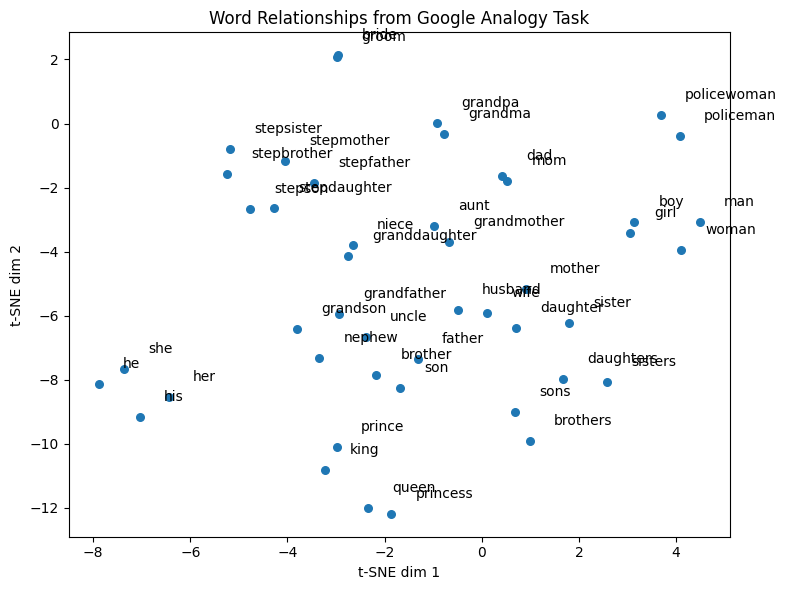

<Figure size 640x480 with 0 Axes>

In [7]:
# 繪製 t-SNE，確認Google Analogy dataset中family子類別詞彙關係
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

SUB_CATEGORY = ": family"

# 1) 篩出 family 類別的題目
family_rows = data[data["SubCategory"] == SUB_CATEGORY]
words = set()
for q in family_rows["Question"]:
    a, b, c, d = q.split()
    words.update([a, b, c, d])

# 2) 過濾 OOV
in_vocab_words = [w for w in words if w in model.key_to_index]
n = len(in_vocab_words)

# 3) 檢查字數是否足夠
if n <= 2:
    raise ValueError(f"詞數太少（{n} 個），t-SNE 無法執行")

# 4) 轉numpy+跑t-SNE
vectors = np.vstack([model[w] for w in in_vocab_words]).astype(np.float32)
perplexity = min(15, n - 1)  

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
    n_iter=2000
)
emb2d = tsne.fit_transform(vectors)

# 5) 畫圖
plt.figure(figsize=(8, 6))
plt.scatter(emb2d[:, 0], emb2d[:, 1], s=30)
for (x, y), w in zip(emb2d, in_vocab_words):
    plt.text(x + 0.5, y + 0.5, w, fontsize=10)


plt.title("Word Relationships from Google Analogy Task")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()
plt.savefig("word_relationships.png", bbox_inches="tight")


### Train embeddings （# 用20%Wikipedia訓練Word2Vec (reference)）

In [7]:
# 資料準備階段:抽樣 20% Wikipedia 文章
!gdown --id 1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd -O wiki_texts_part_0.txt.gz
!gdown --id 1ABblLRd9HXdXvaNv8H9fFq984bhnowoG -O wiki_texts_part_1.txt.gz
!gdown --id 1z2VFNhpPvCejTP5zyejzKj5YjI_Bn42M -O wiki_texts_part_2.txt.gz
!gdown --id 1VKjded9BxADRhIoCzXy_W8uzVOTWIf0g -O wiki_texts_part_3.txt.gz
!gdown --id 16mBeG26m9LzHXdPe8UrijUIc6sHxhknz -O wiki_texts_part_4.txt.gz

/home/claire901114/.local/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd
From (redirected): https://drive.google.com/uc?id=1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd&confirm=t&uuid=1999bd2c-bb8e-4b16-9091-ac8dc4a0ff41
To: /home/claire901114/自然語言處理/HW1/wiki_texts_part_0.txt.gz
100%|██████████████████████████████████████| 1.51G/1.51G [00:36<00:00, 41.9MB/s]
/home/claire901114/.local/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ABblLRd9HXdXvaNv8H9fFq984bhnowoG
From (redirected): https://drive.google.com/uc?id=1ABblLRd

In [8]:
!gdown --id 17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI -O wiki_texts_part_5.txt.gz
!gdown --id 19IvB2vOJRGlrYulnTXlZECR8zT5v550P -O wiki_texts_part_6.txt.gz
!gdown --id 1sjwO8A2SDOKruv6-8NEq7pEIuQ50ygVV -O wiki_texts_part_7.txt.gz
!gdown --id 1s7xKWJmyk98Jbq6Fi1scrHy7fr_ellUX -O wiki_texts_part_8.txt.gz
!gdown --id 17eQXcrvY1cfpKelLbP2BhQKrljnFNykr -O wiki_texts_part_9.txt.gz
!gdown --id 1J5TAN6bNBiSgTIYiPwzmABvGhAF58h62 -O wiki_texts_part_10.txt.gz
     

/home/claire901114/.local/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI
From (redirected): https://drive.google.com/uc?id=17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI&confirm=t&uuid=d089e88e-e4f0-4bb2-b120-63015a94c982
To: /home/claire901114/自然語言處理/HW1/wiki_texts_part_5.txt.gz
100%|████████████████████████████████████████| 578M/578M [00:10<00:00, 55.2MB/s]
/home/claire901114/.local/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19IvB2vOJRGlrYulnTXlZECR8zT5v550P
From (redirected): https://drive.google.com/uc?id=19IvB2vO

In [9]:
# 解壓縮
!gunzip -k wiki_texts_part_*.gz

In [10]:
# 分割檔合併成單一文本檔
!cat wiki_texts_part_*.txt > wiki_texts_combined.txt

In [12]:
# check
!head -n 10 wiki_texts_combined.txt

anarchism is political philosophy and movement that is against all forms of authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy typically including the state and capitalism anarchism advocates for the replacement of the state with stateless societies and voluntary free associations as historically left wing movement this reading of anarchism is placed on the farthest left of the political spectrum usually described as the libertarian wing of the socialist movement libertarian socialism although traces of anarchist ideas are found all throughout history modern anarchism emerged from the enlightenment during the latter half of the th and the first decades of the th century the anarchist movement flourished in most parts of the world and had significant role in workers struggles for emancipation various anarchist schools of thought formed during this period anarchists have taken part in several revolutions most notably in the paris commune

In [4]:
# 抽樣
import random

wiki_txt_path = "wiki_texts_combined.txt"
output_path = "wiki_texts_sampled_20.txt"
# 語料檔說明：
# - wiki_texts_combined.txt 為純文字檔，每行以換行符 (\n) 分隔
# - 每一行代表一篇 Wikipedia 文章（也就是抽樣單位是「文章/行」）

# 抽樣 20% Wikipedia 文章
# 先把所有文章一次讀進記憶體，再用 random.sample 做「不放回抽樣」
with open(wiki_txt_path, "r", encoding="utf-8") as f:
    with open(output_path, "w", encoding="utf-8") as output_file:
    # TODO4: Sample `20%` Wikipedia articles
    # Write your code here

        articles = f.readlines()  # 讀入所有文章
        sample_size = int(len(articles) * 0.2)  # 算 20%
        random.seed(42)  # 固定隨機種子以利重現
        sampled = random.sample(articles, sample_size)  # 抽樣

        output_file.writelines(sampled)  # 輸出
        print(f"原始文章數: {len(articles)}")
        print(f"抽樣文章數: {sample_size}")

原始文章數: 5623655
抽樣文章數: 1124731


In [3]:
# 使用抽樣後的 Wikipedia 語料自行訓練詞向量
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import optuna
import random
import numpy as np
from gensim.utils import tokenize
from tqdm import tqdm
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer


# 下載 NLTK 資源
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english")) # 英文停用詞集合，可用來過濾token
lemmatizer = WordNetLemmatizer() # 詞形還原 降低詞彙稀疏性

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/claire901114/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/claire901114/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/claire901114/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [16]:
from gensim.models import Word2Vec
from gensim.utils import tokenize
from tqdm import tqdm
import datetime

# 逐行讀檔 + 前處理 
class WikiCorpusIter:
    def __init__(self, filepath, stop_words, total_lines=None, use_lemmatize=False, lemmatizer=None):
        self.filepath = filepath
        self.stop_words = stop_words
        self.total_lines = total_lines
        self.use_lemmatize = use_lemmatize
        self.lemmatizer = lemmatizer

    def __iter__(self):
        with open(self.filepath, "r", encoding="utf-8") as f:
            it = f
            if self.total_lines: 
                it = tqdm(f, total=self.total_lines, desc="Processing Wiki")

            for line in it:
                # tokenize: 全部小寫、去標點
                tokens = list(tokenize(line, lowercase=True, deacc=True))

                # 過濾：刪掉純數字，但保留混合型
                tokens = [w for w in tokens if not w.isdigit()]

                # 移除停用詞
                tokens = [w for w in tokens if w not in self.stop_words]

                # 詞形還原
                if self.use_lemmatize and self.lemmatizer is not None:
                    tokens = [self.lemmatizer.lemmatize(w) for w in tokens]

                if tokens:  # 避免空行
                    yield tokens

  


In [10]:
# 計算總行數
with open("wiki_texts_sampled_20.txt", "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)

# 迭代器
sentences = WikiCorpusIter(
    filepath="wiki_texts_sampled_20.txt",
    stop_words=stop_words,
    total_lines=total_lines,
    use_lemmatize=False   
)

# 訓練 Word2Ve
model_own_20 = Word2Vec(
    sentences=sentences,
    vector_size=300,   # 詞向量維度
    window=5,          # 上下文大小
    min_count=2,       # 保留更多低頻詞
    sg=1,              # Skip-gram
    negative=5,        # 負採樣
    epochs=10,         # 訓練輪數
    workers=8,
)

# 4) 保存模型
model_own_20.save("word2vec_wiki20_0925.model")
print("✅ Word2Vec model trained and saved as word2vec_wiki20_0925.model")


Processing Wiki: 100%|██████████| 1124731/1124731 [20:04<00:00, 933.67it/s] 


✅ Word2Vec model trained and saved as word2vec_wiki20_0925.model


In [14]:
data = pd.read_csv("questions-words.csv")

In [15]:
# Analogy預測：使用「自己訓練的 Word2Vec 詞向量」
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    # 使用你自己訓練的詞向量模型進行analogy預測
    # 同時保留每題的標準答案，後續評估用
    # 1) Unpack 四個詞
    a, b, c, d = analogy.lower().split()   # e.g., man woman king queen

    # 2) 保存正解答案
    golds.append(d)

    # 3) 檢查 OOV
    if not all(w in model_own_20.wv.key_to_index for w in (a, b, c)):
        preds.append("<OOV>")
        continue

    # 4) 做向量運算：vector(b) + vector(c) - vector(a)
    try:
        candidates = model_own_20.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=10
        )
        # 5) 避免把 a,b,c 當作答案
        banned = {a, b, c}
        pred = next((w for w, _ in candidates if w not in banned), "<None>")
        preds.append(pred)
    except KeyError:
        preds.append("<OOV>")

100%|██████████| 19544/19544 [15:53<00:00, 20.49it/s]


In [16]:
# 評估
import numpy as np

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 76.00631412786109%
Category: Syntactic, Accuracy: 57.15222482435597%
Sub-Category: capital-common-countries, Accuracy: 95.0592885375494%
Sub-Category: capital-world, Accuracy: 90.45092838196287%
Sub-Category: currency, Accuracy: 9.237875288683602%
Sub-Category: city-in-state, Accuracy: 70.7336846372112%
Sub-Category: family, Accuracy: 67.78656126482213%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 28.528225806451612%
Sub-Category: gram2-opposite, Accuracy: 25.24630541871921%
Sub-Category: gram3-comparative, Accuracy: 74.17417417417418%
Sub-Category: gram4-superlative, Accuracy: 37.076648841354725%
Sub-Category: gram5-present-participle, Accuracy: 47.821969696969695%
Sub-Category: gram6-nationality-adjective, Accuracy: 89.49343339587243%
Sub-Category: gram7-past-tense, Accuracy: 52.88461538461539%
Sub-Category: gram8-plural, Accuracy: 72.82282282282281%
Sub-Category: gram9-plural-verbs, Accuracy: 54.94252873563218%


/home/claire901114/.local/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


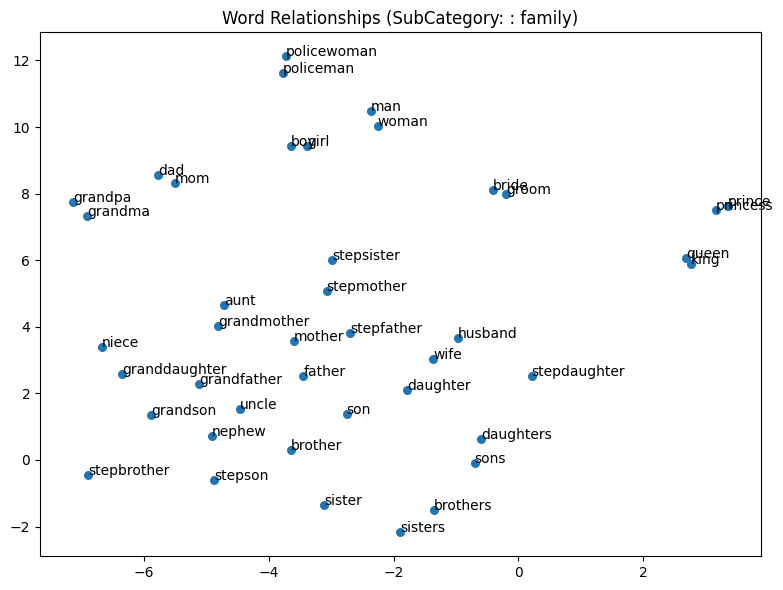

已輸出圖檔：word_relationships_family_word2vec_wiki20_0925.png


In [36]:
# ===== Plot t-SNE for the words in the SUB_CATEGORY `: family` =====
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

SUB_CATEGORY = ": family"

# 1) 從 CSV 讀進來的 data 篩出 family 子類別
family_rows = data[data["SubCategory"] == SUB_CATEGORY]

# 2) 收集該子類別所有出現過的單字
words = set()
for q in family_rows["Question"]:
    a, b, c, d = q.split()
    words.update([a, b, c, d])

# 3) 過濾掉 OOV（只留下自己模型有的詞）
in_vocab_words = [w for w in words if w in model_own_20.wv.key_to_index]
n = len(in_vocab_words)

if n <= 2:
    raise ValueError(f"詞數太少 ({n})，t-SNE 無法執行")

# 4) 取出對應詞向量並轉 numpy array
vectors = np.vstack([model_own_20.wv[w] for w in in_vocab_words]).astype(np.float32)
perplexity = min(15, n - 1) 
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
    n_iter=2000
)

emb2d = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 6))
plt.scatter(emb2d[:, 0], emb2d[:, 1], s=30)

for (x, y), w in zip(emb2d, in_vocab_words):
    plt.text(x, y, w, fontsize=10)  # 不要偏移

plt.title(f"Word Relationships (SubCategory: {SUB_CATEGORY})")
plt.tight_layout()
plt.savefig("word_relationships_family_word2vec_wiki20_0925.png", bbox_inches="tight", dpi=150)
plt.show()
print("已輸出圖檔：word_relationships_family_word2vec_wiki20_0925.png")


### 5% Wikipedia Train

In [2]:
# 改成 5% 抽樣檔案
import random

wiki_txt_path = "wiki_texts_combined.txt"
output_path = "wiki_texts_sampled_5.txt"  

with open(wiki_txt_path, "r", encoding="utf-8") as f:
    with open(output_path, "w", encoding="utf-8") as output_file:
        articles = f.readlines()
        sample_size = int(len(articles) * 0.05)  # 抽 5%
        random.seed(42)  # 固定隨機種子
        sampled = random.sample(articles, sample_size)
        output_file.writelines(sampled)
        print(f"原始文章數: {len(articles)}")
        print(f"抽樣文章數: {sample_size}")


原始文章數: 5623655
抽樣文章數: 281182


In [12]:
# 1) 計算總行數（用於 tqdm）
with open("wiki_texts_sampled_5.txt", "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)

# 2) 建立迭代器
#sentences = WikiCorpusIter("wiki_texts_sampled_5.txt", stop_words, lemmatizer, total_lines)
sentences = WikiCorpusIter(
    filepath="wiki_texts_sampled_5.txt",
    stop_words=stop_words,
    total_lines=total_lines,
    use_lemmatize=False   
)
# 3) 訓練 Word2Vec 模型（固定參數）
model_own_5 = Word2Vec(
    sentences=sentences,
    vector_size=300,   
    window=5,          
    min_count=2,       
    sg=1,              
    negative=5,       
    epochs=10,         
    workers=8,
)

# 存模型
model_own_5.save("word2vec_wiki5_0926.model")
print("Word2Vec model trained and saved as word2vec_wiki5_0926.model")

Processing Wiki: 100%|██████████| 281182/281182 [04:53<00:00, 957.44it/s] 


Word2Vec model trained and saved as word2vec_wiki5_0926.model


In [13]:
data = pd.read_csv("questions-words.csv")

In [14]:
# Analogy 預測
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    #使用你自己訓練的詞向量模型進行 analogy預測
    # 1) Unpack 四個詞
    a, b, c, d = analogy.lower().split()   # a, b, c, d = analogy.split()   # e.g., man woman king queen

    # 2) 保存正解答案 (word_d)
    golds.append(d)

    # 3) 檢查 OOV（只要 a,b,c 不在模型裡就跳過）
    if not all(w in model_own_5.wv.key_to_index for w in (a, b, c)):
        preds.append("<OOV>")
        continue

    # 4) 做向量運算：vector(b) + vector(c) - vector(a)
    try:
        candidates = model_own_5.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=10
        )
        # 5) 避免把 a,b,c 當作答案
        banned = {a, b, c}
        pred = next((w for w, _ in candidates if w not in banned), "<None>")
        preds.append(pred)
    except KeyError:
        preds.append("<OOV>")

100%|██████████| 19544/19544 [06:36<00:00, 49.24it/s]


In [15]:
# Evaluation
def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 71.57514939677529%
Category: Syntactic, Accuracy: 48.19672131147541%
Sub-Category: capital-common-countries, Accuracy: 95.65217391304348%
Sub-Category: capital-world, Accuracy: 84.94694960212202%
Sub-Category: currency, Accuracy: 3.233256351039261%
Sub-Category: city-in-state, Accuracy: 69.88244831779488%
Sub-Category: family, Accuracy: 53.16205533596838%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 14.616935483870968%
Sub-Category: gram2-opposite, Accuracy: 15.024630541871922%
Sub-Category: gram3-comparative, Accuracy: 61.786786786786784%
Sub-Category: gram4-superlative, Accuracy: 22.54901960784314%
Sub-Category: gram5-present-participle, Accuracy: 37.40530303030303%
Sub-Category: gram6-nationality-adjective, Accuracy: 88.11757348342715%
Sub-Category: gram7-past-tense, Accuracy: 52.43589743589744%
Sub-Category: gram8-plural, Accuracy: 61.711711711711715%
Sub-Category: gram9-plural-verbs, Accuracy: 41.14942528735632%


### 10% Wikipedia Train

In [3]:
# 改成 10% 抽樣檔案
wiki_txt_path = "wiki_texts_combined.txt"
output_path = "wiki_texts_sampled_10.txt"


with open(wiki_txt_path, "r", encoding="utf-8") as f:
    with open(output_path, "w", encoding="utf-8") as output_file:

        articles = f.readlines()  
        sample_size = int(len(articles) * 0.1)  
        random.seed(42)  
        sampled = random.sample(articles, sample_size)  

        output_file.writelines(sampled) 
        print(f"原始文章數: {len(articles)}")
        print(f"抽樣文章數: {sample_size}")

原始文章數: 5623655
抽樣文章數: 562365


In [17]:
# 1) 計算總行數
with open("wiki_texts_sampled_10.txt", "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)

# 2) 建立迭代器
sentences = WikiCorpusIter("wiki_texts_sampled_10.txt", stop_words, lemmatizer, total_lines)
sentences = WikiCorpusIter(
    filepath="wiki_texts_sampled_10.txt",
    stop_words=stop_words,
    total_lines=total_lines,
    use_lemmatize=False   
)
# 3) 訓練模型
model_own_10 = Word2Vec(
    sentences=sentences,
    vector_size=300,   
    window=5,          
    min_count=2,       
    sg=1,              
    negative=5,        
    epochs=10,         
    workers=8,
)

# 存模型
model_own_5.save("word2vec_wiki10_0926.model")
print("Word2Vec model trained and saved as word2vec_wiki10_0926.model")

Processing Wiki: 100%|██████████| 562365/562365 [09:49<00:00, 954.27it/s] 


Word2Vec model trained and saved as word2vec_wiki10_0926.model


In [18]:
data = pd.read_csv("questions-words.csv")

In [19]:
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    # TODO6: 使用你自己訓練的詞向量模型進行 analogy 預測
    # 1) Unpack 四個詞
    a, b, c, d = analogy.lower().split()   # a, b, c, d = analogy.split()   # e.g., man woman king queen

    # 2) 保存正解答案
    golds.append(d)

    # 3) 檢查 OOV
    if not all(w in model_own_10.wv.key_to_index for w in (a, b, c)):
        preds.append("<OOV>")
        continue

    # 4) 做向量運算：vector(b) + vector(c) - vector(a)
    try:
        candidates = model_own_10.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=10
        )
        # 5) 避免把 a,b,c當答案
        banned = {a, b, c}
        pred = next((w for w, _ in candidates if w not in banned), "<None>")
        preds.append(pred)
    except KeyError:
        preds.append("<OOV>")

100%|██████████| 19544/19544 [10:56<00:00, 29.76it/s]


In [20]:
# Evaluation
def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 75.43127748336904%
Category: Syntactic, Accuracy: 52.08430913348946%
Sub-Category: capital-common-countries, Accuracy: 95.8498023715415%
Sub-Category: capital-world, Accuracy: 90.14146772767462%
Sub-Category: currency, Accuracy: 6.1200923787528865%
Sub-Category: city-in-state, Accuracy: 71.66599108228617%
Sub-Category: family, Accuracy: 60.47430830039525%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 20.766129032258064%
Sub-Category: gram2-opposite, Accuracy: 19.458128078817737%
Sub-Category: gram3-comparative, Accuracy: 67.56756756756756%
Sub-Category: gram4-superlative, Accuracy: 27.629233511586452%
Sub-Category: gram5-present-participle, Accuracy: 44.034090909090914%
Sub-Category: gram6-nationality-adjective, Accuracy: 89.36835522201376%
Sub-Category: gram7-past-tense, Accuracy: 51.92307692307693%
Sub-Category: gram8-plural, Accuracy: 66.29129129129129%
Sub-Category: gram9-plural-verbs, Accuracy: 45.86206896551724%


# B.	訓練語料庫的差異性分析

### 用抽樣25%News Crawl 訓練

In [1]:
# 確認原先 wiki_texts_sampled_20.txt 的 token數 
from tqdm import tqdm

file_path = "wiki_texts_sampled_20.txt"

total_tokens = 0
with open(file_path, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Counting tokens"):
        tokens = line.strip().split()  
        total_tokens += len(tokens)

print(f"總詞數 (tokens): {total_tokens:,}")


Counting tokens: 1124731it [00:36, 30859.10it/s]

總詞數 (tokens): 671,986,897


In [1]:
%cd /work/claire901114


/work/claire901114


In [2]:
# 建立資料夾
!mkdir -p /work/claire901114/newscrawl
%cd /work/claire901114/newscrawl

# 下載 2019–2021 三年語料
!wget https://data.statmt.org/news-crawl/en/news.2019.en.shuffled.deduped.gz
!wget https://data.statmt.org/news-crawl/en/news.2020.en.shuffled.deduped.gz
!wget https://data.statmt.org/news-crawl/en/news.2021.en.shuffled.deduped.gz



/work/claire901114/newscrawl
--2025-09-22 10:32:08--  https://data.statmt.org/news-crawl/en/news.2019.en.shuffled.deduped.gz
Resolving data.statmt.org (data.statmt.org)... 129.215.32.28
Connecting to data.statmt.org (data.statmt.org)|129.215.32.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2190693542 (2.0G) [application/x-gzip]
Saving to: ‘news.2019.en.shuffled.deduped.gz’

news.2019.en.shuffl 100%[===================>]   2.04G  13.0MB/s    in 2m 50s  

2025-09-22 10:34:59 (12.3 MB/s) - ‘news.2019.en.shuffled.deduped.gz’ saved [2190693542/2190693542]

--2025-09-22 10:34:59--  https://data.statmt.org/news-crawl/en/news.2020.en.shuffled.deduped.gz
Resolving data.statmt.org (data.statmt.org)... 129.215.32.28
Connecting to data.statmt.org (data.statmt.org)|129.215.32.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2719983703 (2.5G) [application/x-gzip]
Saving to: ‘news.2020.en.shuffled.deduped.gz’

news.2020.en.shuffl 100%[=======

In [3]:
# 解壓縮
!gunzip /work/claire901114/newscrawl/news.2019.en.shuffled.deduped.gz
!gunzip /work/claire901114/newscrawl/news.2020.en.shuffled.deduped.gz
!gunzip /work/claire901114/newscrawl/news.2021.en.shuffled.deduped.gz



In [4]:
# 切換到存放解壓縮檔的資料夾
%cd /work/claire901114/newscrawl
# 合併三年資料
!cat news.2019.en.shuffled.deduped \
     news.2020.en.shuffled.deduped \
     news.2021.en.shuffled.deduped \
     > /work/claire901114/newscrawl/news_2019_2021.txt

/work/claire901114/newscrawl


In [5]:
# 確認 news_2019_2021.txt tokens
total_tokens = 0
with open("/work/claire901114/newscrawl/news_2019_2021.txt", "r", encoding="utf-8") as f:
    for line in f:
        total_tokens += len(line.strip().split())
print(f"總詞數 (tokens): {total_tokens:,}")


總詞數 (tokens): 2,886,958,305


In [6]:
import random

input_file = "/work/claire901114/newscrawl/news_2019_2021.txt"
output_file = "/work/claire901114/newscrawl/news_sample_25.txt"

random.seed(42)

with open(input_file, "r", encoding="utf-8") as f_in:
    lines = f_in.readlines()
    sample_size = int(len(lines) * 0.25)  # 抽 25%，希望與 wiki_texts_sampled_20.txt 的 token數差異不大，利於比較
    sampled = random.sample(lines, sample_size)
    with open(output_file, "w", encoding="utf-8") as f_out:
        f_out.writelines(sampled)

print(f"抽樣完成，共抽 {sample_size:,} 行，輸出到 {output_file}")


抽樣完成，共抽 28,597,683 行，輸出到 /work/claire901114/newscrawl/news_sample_25.txt


In [5]:
# 1) 計算 News Crawl 25% 的總行數
news_file = "/work/claire901114/newscrawl/news_sample_25.txt"
with open(news_file, "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)

print(f"News Crawl 抽樣檔總行數: {total_lines:,}")

# 2) 建立迭代器
# sentences_news = WikiCorpusIter(news_file, stop_words, lemmatizer, total_lines)
sentences = WikiCorpusIter(
    news_file,
    stop_words=stop_words,
    total_lines=total_lines,
    use_lemmatize=False   
)
# 3) 訓練 Word2Vec 模型（參數一致）
model_news_25 = Word2Vec(
    sentences=sentences,
    vector_size=300,   
    window=5,          
    min_count=2,       
    sg=1,              
    negative=5,        
    epochs=10,         
    workers=8,
)


# 存模型
model_news_25.save("word2vec_news_25_0926.model")
print("Word2Vec model trained and saved as word2vec_news_25_0926.model")

News Crawl 抽樣檔總行數: 28,597,683


Processing Wiki: 100%|██████████| 28597683/28597683 [23:38<00:00, 20154.15it/s]


Word2Vec model trained and saved as word2vec_news_25_0926.model


In [7]:
data = pd.read_csv("questions-words.csv")

In [8]:
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    # 使用你自己訓練的詞向量模型進行 analogy 預測
    # 1) Unpack 四個詞
    a, b, c, d = analogy.lower().split()   # a, b, c, d = analogy.split()   # e.g., man woman king queen

    # 2) 保存正解答案 (word_d)
    golds.append(d)

    # 3) 檢查 OOV（只要 a,b,c 不在模型裡就跳過）
    if not all(w in model_news_25.wv.key_to_index for w in (a, b, c)):
        preds.append("<OOV>")
        continue

    # 4) 做向量運算：vector(b) + vector(c) - vector(a)
    try:
        candidates = model_news_25.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=10
        )
        # 避免把 a,b,c當作答案
        banned = {a, b, c}
        pred = next((w for w, _ in candidates if w not in banned), "<None>")
        preds.append(pred)
    except KeyError:
        preds.append("<OOV>")

100%|██████████| 19544/19544 [05:46<00:00, 56.40it/s]


In [10]:
# Evaluation
import numpy as np

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 67.5611681136543%
Category: Syntactic, Accuracy: 66.65105386416862%
Sub-Category: capital-common-countries, Accuracy: 91.10671936758892%
Sub-Category: capital-world, Accuracy: 79.59770114942529%
Sub-Category: currency, Accuracy: 8.429561200923787%
Sub-Category: city-in-state, Accuracy: 63.39683826509931%
Sub-Category: family, Accuracy: 57.905138339920946%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 30.141129032258064%
Sub-Category: gram2-opposite, Accuracy: 32.389162561576356%
Sub-Category: gram3-comparative, Accuracy: 87.23723723723724%
Sub-Category: gram4-superlative, Accuracy: 69.6969696969697%
Sub-Category: gram5-present-participle, Accuracy: 72.63257575757575%
Sub-Category: gram6-nationality-adjective, Accuracy: 89.36835522201376%
Sub-Category: gram7-past-tense, Accuracy: 67.56410256410257%
Sub-Category: gram8-plural, Accuracy: 66.8918918918919%
Sub-Category: gram9-plural-verbs, Accuracy: 53.79310344827586%


In [30]:
# Select a few words and retrieve top-5 most similar words
from gensim.models import Word2Vec
# 載入你之前存好的新聞模型
model_own_20 = Word2Vec.load("word2vec_wiki20_0925.model")

test_words = ["king", "apple", "university", "doctor", "computer"]

for word in test_words:
    if word in model_own_20.wv.key_to_index:
        print(f"\nTop-5 similar words for '{word}':")
        similar = model_own_20.wv.most_similar(word, topn=5)
        for sim_word, score in similar:
            print(f"  {sim_word:<15} (cosine similarity: {score:.4f})")
    else:
        print(f"\nWord '{word}' not in vocabulary.")



Top-5 similar words for 'king':
  queen           (cosine similarity: 0.6693)
  monarch         (cosine similarity: 0.6257)
  kings           (cosine similarity: 0.6243)
  buwanekabahu    (cosine similarity: 0.5985)
  throne          (cosine similarity: 0.5966)

Top-5 similar words for 'apple':
  colormonitor    (cosine similarity: 0.6412)
  iphone          (cosine similarity: 0.6339)
  blackberry      (cosine similarity: 0.6256)
  homepod         (cosine similarity: 0.6183)
  iigs            (cosine similarity: 0.6105)

Top-5 similar words for 'university':
  college         (cosine similarity: 0.6935)
  faculty         (cosine similarity: 0.6858)
  doctorate       (cosine similarity: 0.6825)
  undergraduate   (cosine similarity: 0.6782)
  phd             (cosine similarity: 0.6669)

Top-5 similar words for 'doctor':
  bovinity        (cosine similarity: 0.6157)
  doctors         (cosine similarity: 0.5909)
  irrefragabilis  (cosine similarity: 0.5869)
  dmedsc          (cosine simil

In [31]:
# Select a few words and retrieve top-5 most similar words
# 載入你之前存好的新聞模型
model_news_25 = Word2Vec.load("word2vec_news_25_0926.model")

# 測試詞清單
test_words = ["king", "apple", "university", "doctor", "computer"]

# 檢索相似詞
for word in test_words:
    if word in model_news_25.wv.key_to_index:
        print(f"\nTop-5 similar words for '{word}':")
        similar = model_news_25.wv.most_similar(word, topn=5)
        for sim_word, score in similar:
            print(f"  {sim_word:<15} (cosine similarity: {score:.4f})")
    else:
        print(f"\nWord '{word}' not in vocabulary.")



Top-5 similar words for 'king':
  harthacnut      (cosine similarity: 0.6550)
  capard          (cosine similarity: 0.6269)
  prajadhipok     (cosine similarity: 0.6068)
  rtin            (cosine similarity: 0.6021)
  bhumibhol       (cosine similarity: 0.5952)

Top-5 similar words for 'apple':
  aapl            (cosine similarity: 0.7466)
  iphone          (cosine similarity: 0.7222)
  iphones         (cosine similarity: 0.7086)
  ios             (cosine similarity: 0.6574)
  google          (cosine similarity: 0.6477)

Top-5 similar words for 'university':
  professor       (cosine similarity: 0.7286)
  sociology       (cosine similarity: 0.6957)
  univeristy      (cosine similarity: 0.6902)
  lecturer        (cosine similarity: 0.6782)
  univesity       (cosine similarity: 0.6646)

Top-5 similar words for 'doctor':
  physician       (cosine similarity: 0.7102)
  doctors         (cosine similarity: 0.6849)
  nurse           (cosine similarity: 0.6444)
  dentist         (cosine simil

# C.類比推理演算法的效能評估

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# 定義「Syntactic 子類別」順序
SYN_ORDER = [
    "gram1-adjective-to-adverb",
    "gram2-opposite",
    "gram3-comparative",
    "gram4-superlative",
    "gram5-present-participle",
    "gram6-nationality-adjective",
    "gram7-past-tense",
    "gram8-plural",
    "gram9-plural-verbs",
]

def evaluate_topk(model, filepath="questions-words.csv", topk=10, use_cosmul=False):
    """
    目的：
      - 針對Google Analogy Dataset做 top-k 類比評估
      - 同時回傳overall/category/subcategory 的Hit@k ，方便做表格或畫圖

    參數：
      - model: 訓練好的 gensim Word2Vec 
      - filepath: questions-words.csv 路徑
      - topk: 你想看的候選名次範圍
      - use_cosmul:
          True  -> 使用 most_similar_cosmul（cosmul 類比方法）
          False -> 使用 most_similar（加減法類比：vec(b)+vec(c)-vec(a)）

    回傳：
      - overall_acc (Hit@1)
      - cat_acc: {Category: Hit@1}
      - sub_hitk: {SubCategory: {"hit1":..., "hit3":..., "hit10":..., "n":...}}
      - sub_acc: {SubCategory: Hit@1}
    """
    data = pd.read_csv(filepath)

    # 解析 Question 欄（格式：a b c d）
    ABCD = data["Question"].str.lower().str.split(expand=True)
    ABCD.columns = ["a","b","c","d"]

    preds_topk = []  # 每題的 top-k 預測清單
    golds = ABCD["d"].to_numpy()

    for a,b,c,_d in tqdm(ABCD.itertuples(index=False), total=len(ABCD), desc="Evaluating"):
        # OOV 檢查
        if not all(w in model.wv.key_to_index for w in (a,b,c)):
            preds_topk.append(["<OOV>"])
            continue

        try:
            if use_cosmul:
                cands = model.wv.most_similar_cosmul(positive=[b,c], negative=[a], topn=topk+3)
            else:
                cands = model.wv.most_similar(positive=[b,c], negative=[a], topn=topk+3)

            banned = {a,b,c}
            filtered = [w for (w,_) in cands if w not in banned][:topk]
            if not filtered:
                filtered = ["<None>"]
            preds_topk.append(filtered)
        except KeyError:
            preds_topk.append(["<OOV>"])

    preds_topk = np.array(preds_topk, dtype=object)

    # Hit@k計算工具 
    def hit_at_k(golds, preds_lists, k):
        mask = np.array([p[0] != "<OOV>" for p in preds_lists])
        if mask.sum() == 0:
            return 0.0
        hits = sum(g in p[:k] for g, p in zip(golds[mask], preds_lists[mask]))
        return hits / mask.sum()

    # Overall（Hit@1當作accuracy）
    overall_acc = hit_at_k(golds, preds_topk, k=1)

    # Category
    cat_acc = {}
    for cat in data["Category"].unique():
        mask = (data["Category"] == cat).to_numpy()
        cat_acc[cat] = hit_at_k(golds[mask], preds_topk[mask], k=1) * 100

    # SubCategory（Hit@1/3/10 & Hit@1當acc）
    sub_hitk, sub_acc = {}, {}
    for sub in data["SubCategory"].unique():
        mask = (data["SubCategory"] == sub).to_numpy()
        if mask.sum() == 0:
            continue
        h1 = hit_at_k(golds[mask], preds_topk[mask], k=1)
        h3 = hit_at_k(golds[mask], preds_topk[mask], k=3)
        h10 = hit_at_k(golds[mask], preds_topk[mask], k=10)
        sub_hitk[sub] = {"hit1": h1*100, "hit3": h3*100, "hit10": h10*100, "n": int(mask.sum())}
        sub_acc[sub] = h1*100

    return overall_acc*100, cat_acc, sub_hitk, sub_acc


In [10]:
model_own_20 = Word2Vec.load("word2vec_wiki20_0925.model")

# 3CosAdd (baseline)
overall_add, cat_add, sub_hitk_add, sub_acc_add = evaluate_topk(
    model_own_20, "questions-words.csv", topk=1, use_cosmul=False
)

# 3CosMul
overall_mul, cat_mul, sub_hitk_mul, sub_acc_mul = evaluate_topk(
    model_own_20, "questions-words.csv", topk=1, use_cosmul=True
)

print("Word2Vec (3CosAdd):", f"{overall_add:.2f}%")
print("Word2Vec (3CosMul):", f"{overall_mul:.2f}%")




Evaluating: 100%|██████████| 19544/19544 [41:45<00:00,  7.80it/s]


Word2Vec (3CosAdd): 66.31%
Word2Vec (3CosMul): 67.29%


In [11]:
import pandas as pd

rows = []
for subcat in sub_acc_add:
    acc_add = sub_acc_add.get(subcat, 0.0)
    acc_mul = sub_acc_mul.get(subcat, 0.0)
    delta = acc_mul - acc_add
    rows.append({"SubCategory": subcat, "3CosAdd": acc_add, "3CosMul": acc_mul, "Δ": delta})

df_diff = pd.DataFrame(rows)
df_diff = df_diff.sort_values("Δ", ascending=False)
print(df_diff)


                      SubCategory    3CosAdd    3CosMul         Δ
13           : gram9-plural-verbs  54.942529  62.873563  7.931034
8             : gram4-superlative  37.076649  43.939394  6.862745
11             : gram7-past-tense  52.884615  57.371795  4.487179
2                      : currency   9.557945  11.589008  2.031063
9      : gram5-present-participle  47.821970  48.768939  0.946970
7             : gram3-comparative  74.174174  74.624625  0.450450
0      : capital-common-countries  95.059289  95.454545  0.395257
1                 : capital-world  90.450928  90.340407 -0.110522
10  : gram6-nationality-adjective  89.493433  89.305816 -0.187617
3                 : city-in-state  70.733685  70.085124 -0.648561
5     : gram1-adjective-to-adverb  30.430108  29.569892 -0.860215
12                 : gram8-plural  72.822823  71.771772 -1.051051
4                        : family  81.666667  80.476190 -1.190476
6                : gram2-opposite  25.246305  24.014778 -1.231527
